# HouseTS — Stacking Ensemble (ElasticNet + RandomForest + XGBoost)

Notebook này đi từng bước: load → clean (loại leakage) → feature engineering
→ time-based split → **rolling-window CV** (vài fold cuối, train size lớn)
→ train meta-model → so sánh với từng base model → phân tích chiều sâu
(residual correlation, feature importance).

**Mục tiêu**: ở mỗi bước, quan sát output/biểu đồ để hiểu điều gì đang xảy ra
và tại sao — không chỉ chạy cho ra kết quả cuối cùng.

> ⚙️ Mặc định notebook chạy trên **sample nhỏ (~3% zipcode, ~25-30K dòng)** để
> chạy nhanh (vài phút), giúp bạn xem hết pipeline trước. Khi đã hiểu rõ từng
> bước, tăng `SAMPLE_FRAC` (hoặc đặt `= 1.0` để chạy full 884K dòng) và tăng
> `n_estimators` của RandomForest/XGBoost để có kết quả đáng tin cậy hơn cho
> báo cáo cuối cùng.

> 🔧 **Lịch sử các lần đổi cách sinh dữ liệu cho meta-model** (đáng đọc để hiểu
> trade-off, không phải chỉ đổi cho có):
> 1. **TimeSeriesSplit nhiều fold (expanding window từ đầu)** — dùng được
>    nhiều dữ liệu OOF, nhưng fold đầu train trên rất ít dữ liệu → thiên vị
>    (bias) đánh giá thấp các model cần nhiều data (RandomForest).
> 2. **Blending (1 holdout cố định ở cuối train)** — hết bias vì base model
>    luôn train trên phần lớn dữ liệu, nhưng chỉ có 1 "cửa sổ thời gian" duy
>    nhất để học trọng số → trọng số dễ nhiễu (variance cao) nếu giai đoạn đó
>    có gì bất thường.
> 3. **Rolling-window CV (bản hiện tại)** — cân bằng cả 2: tạo nhiều fold
>    bằng `TimeSeriesSplit` nhưng CHỈ dùng vài fold CUỐI (train size đã đủ
>    lớn, ví dụ ≥70% train set) → vừa giảm bias (không có fold quá nhỏ), vừa
>    giảm variance so với 1 holdout (vài cửa sổ thời gian khác nhau thay vì
>    một).

## Bước 0 — Setup

Import thư viện, cấu hình sample size & hyperparameters. Import lại toàn bộ
hàm preprocess từ `preprocess_housets.py` (đã tách file riêng) để không lặp
code.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.optimize import nnls
from xgboost import XGBRegressor

from preprocess_housets import load_and_clean, time_based_split, encode_and_scale, transform_target, TARGET

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Config: chỉnh ở đây để chạy full data hoặc thay đổi model ──
DATA_PATH        = "data/HouseTS.csv"
CUTOFF_DATE      = "2022-06-30"   # train <= cutoff, test > cutoff
SAMPLE_FRAC      = 1.0            # % zipcode giữ lại để chạy nhanh. Đặt 1.0 = full data.
N_SPLITS_TOTAL   = 6               # tổng số fold TimeSeriesSplit tạo ra (để fold cuối có train size lớn)
N_FOLDS_USED     = 3               # chỉ dùng N_FOLDS_USED fold CUỐI (train size đã lớn) để học trọng số meta-model

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 100

## Bước 1 — Load dữ liệu thô

Xem nhanh cấu trúc, kích thước, và khoảng thời gian dữ liệu bao phủ trước khi
xử lý gì cả.

In [2]:
raw = pd.read_csv(DATA_PATH)
print(f"Shape gốc: {raw.shape}")
print(f"Khoảng thời gian: {raw['date'].min()} → {raw['date'].max()}")
print(f"Số zipcode: {raw['zipcode'].nunique()}  |  Số city: {raw['city'].nunique()}")
raw.head(3)

Shape gốc: (884092, 39)
Khoảng thời gian: 2012-03-31 → 2023-12-31
Số zipcode: 6226  |  Số city: 30


,date,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,city,zipcode,year,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full
0,2012-03-31,46550.0,217450.0,31.813674,110.183666,14.0,23.0,44.0,64.0,59.5,0.943662,0.142857,0.043478,ATL,30002,2012,12.0,2.0,4.0,1.0,60.0,45.0,57.0,4.0,7.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,200773.999557,Atlanta-Sandy Springs-Alpharetta
1,2012-04-30,61870.0,245000.0,40.723982,130.528256,22.0,29.0,56.0,69.0,89.5,0.946642,0.090909,0.034483,ATL,30002,2012,12.0,2.0,4.0,1.0,60.0,45.0,57.0,4.0,7.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,202421.064584,Atlanta-Sandy Springs-Alpharetta
2,2012-05-31,125500.0,217450.0,63.913043,119.919216,24.0,40.0,63.0,60.0,144.5,0.955624,0.208333,0.100000,ATL,30002,2012,12.0,2.0,4.0,1.0,60.0,45.0,57.0,4.0,7.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,202681.309539,Atlanta-Sandy Springs-Alpharetta


In [3]:
if SAMPLE_FRAC < 1.0:
    keep_zips = raw["zipcode"].drop_duplicates().sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED)
    raw_sample = raw[raw["zipcode"].isin(keep_zips)]
    raw_sample.to_csv("data/HouseTS_sample.csv", index=False)
    DATA_PATH_USED = "data/HouseTS_sample.csv"
    print(f"Đã lấy sample {SAMPLE_FRAC*100:.0f}% zipcode -> {raw_sample.shape[0]:,} dòng "
          f"({raw_sample['zipcode'].nunique()} zipcode)")
else:
    DATA_PATH_USED = DATA_PATH
    print("Dùng full dataset.")

Dùng full dataset.


## Bước 2 — Vì sao loại các cột leakage?

Trước khi gọi `clean()`, hãy tự nhìn correlation giữa các cột bị nghi ngờ
leakage với target `price`. Đây là bằng chứng trực tiếp — không phải loại bỏ
theo cảm tính.

Correlation với target (price) — càng cao càng leak:
median_sale_price    0.918
Median Home Value    0.834
median_list_ppsf     0.586
median_ppsf          0.233
median_list_price    0.205
sold_above_list      0.158
avg_sale_to_list     0.141
Name: price, dtype: float64


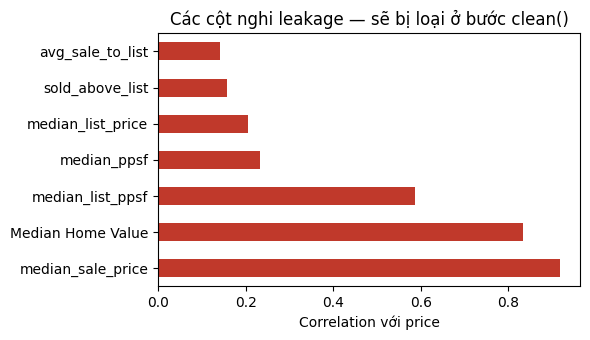

In [4]:
LEAKY_CANDIDATES = ["median_sale_price", "median_list_price", "median_ppsf",
                     "median_list_ppsf", "avg_sale_to_list", "sold_above_list",
                     "Median Home Value"]
corr_with_target = raw[LEAKY_CANDIDATES + ["price"]].corr()["price"].drop("price").sort_values(ascending=False)
print("Correlation với target (price) — càng cao càng leak:")
print(corr_with_target.round(3))

fig, ax = plt.subplots(figsize=(6, 3.5))
corr_with_target.plot(kind="barh", ax=ax, color="#c0392b")
ax.set_xlabel("Correlation với price")
ax.set_title("Các cột nghi leakage — sẽ bị loại ở bước clean()")
plt.tight_layout()
plt.show()

In [5]:
df_clean = load_and_clean(DATA_PATH_USED)
print(f"\nSau clean + engineer: {df_clean.shape[0]:,} dòng x {df_clean.shape[1]} cột")
df_clean.head(3)

[load]  Rows: 884,092  |  Columns: 39
[clean] Removed 0 rows with price <= 0
[clean] Missing values before: 0, after: 0
[clean] Dropped 7 leakage columns: ['median_sale_price', 'median_ppsf', 'median_list_ppsf', 'avg_sale_to_list', 'sold_above_list', 'median_list_price', 'Median Home Value']
[clean] Dropped 1 redundant columns: ['city_full']
[clean] Remaining rows: 884,092, columns: 31
[engineer] Feature count: 45 features (target excluded)

[pipeline] EDA-ready DataFrame: 884,092 rows × 46 cols

Sau clean + engineer: 884,092 dòng x 46 cột


,date,homes_sold,pending_sales,new_listings,inventory,median_dom,off_market_in_two_weeks,city,zipcode,year,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,month,quarter,poi_total,poi_per_1000_pop,poverty_rate,unemployment_rate,school_enrollment_rate,housing_units_per_capita,rent_to_income_ratio,log_Total_Population,log_Per_Capita_Income,log_inventory,log_homes_sold,log_new_listings,log_pending_sales
0,2012-03-31,14.0,23.0,44.0,64.0,59.5,0.043478,ATL,30002,2012,12.0,2.0,4.0,1.0,60.0,45.0,57.0,4.0,7.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,3171.0,460.0,5408.0,5408.0,2492.0,200773.999557,3,1,192.0,28.189693,0.999828,0.145019,0.999815,0.460599,0.257768,8.66768,10.405868,4.174387,2.708050,3.806662,3.178054
1,2012-04-30,22.0,29.0,56.0,69.0,89.5,0.034483,ATL,30002,2012,12.0,2.0,4.0,1.0,60.0,45.0,57.0,4.0,7.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,3171.0,460.0,5408.0,5408.0,2492.0,202421.064584,4,2,192.0,28.189693,0.999828,0.145019,0.999815,0.460599,0.257768,8.66768,10.405868,4.248495,3.135494,4.043051,3.401197
2,2012-05-31,24.0,40.0,63.0,60.0,144.5,0.100000,ATL,30002,2012,12.0,2.0,4.0,1.0,60.0,45.0,57.0,4.0,7.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,3171.0,460.0,5408.0,5408.0,2492.0,202681.309539,5,2,192.0,28.189693,0.999828,0.145019,0.999815,0.460599,0.257768,8.66768,10.405868,4.110874,3.218876,4.158883,3.713572


## Bước 3 — Quan sát các feature mới được tạo ra

`engineer_features()` (được gọi bên trong `load_and_clean`) đã tạo thêm các
tỷ lệ (rate) và log-transform. Xem thử phân phối của vài feature mới để kiểm
tra chúng có hợp lý không (không có giá trị âm/vô cực bất thường).

In [6]:
new_feats = ["poverty_rate", "unemployment_rate", "school_enrollment_rate",
             "housing_units_per_capita", "rent_to_income_ratio", "poi_per_1000_pop"]
df_clean[new_feats].describe().T

,count,mean,std,min,25%,50%,75%,max
poverty_rate,884092.0,0.907960,0.264391,0.0,0.981995,0.993133,0.997516,0.999984
unemployment_rate,884092.0,0.065180,0.045466,0.0,0.038141,0.058218,0.085290,0.835616
school_enrollment_rate,884092.0,0.923499,0.265285,0.0,0.999771,0.999942,0.999969,0.999992
housing_units_per_capita,884092.0,0.421201,1.332280,0.0,0.349111,0.396232,0.453870,196.000000
rent_to_income_ratio,884092.0,0.402034,0.191853,0.0,0.301317,0.393110,0.505860,2.456389
poi_per_1000_pop,884092.0,23.838518,94.416154,0.0,1.682935,4.498021,12.187116,3609.000000


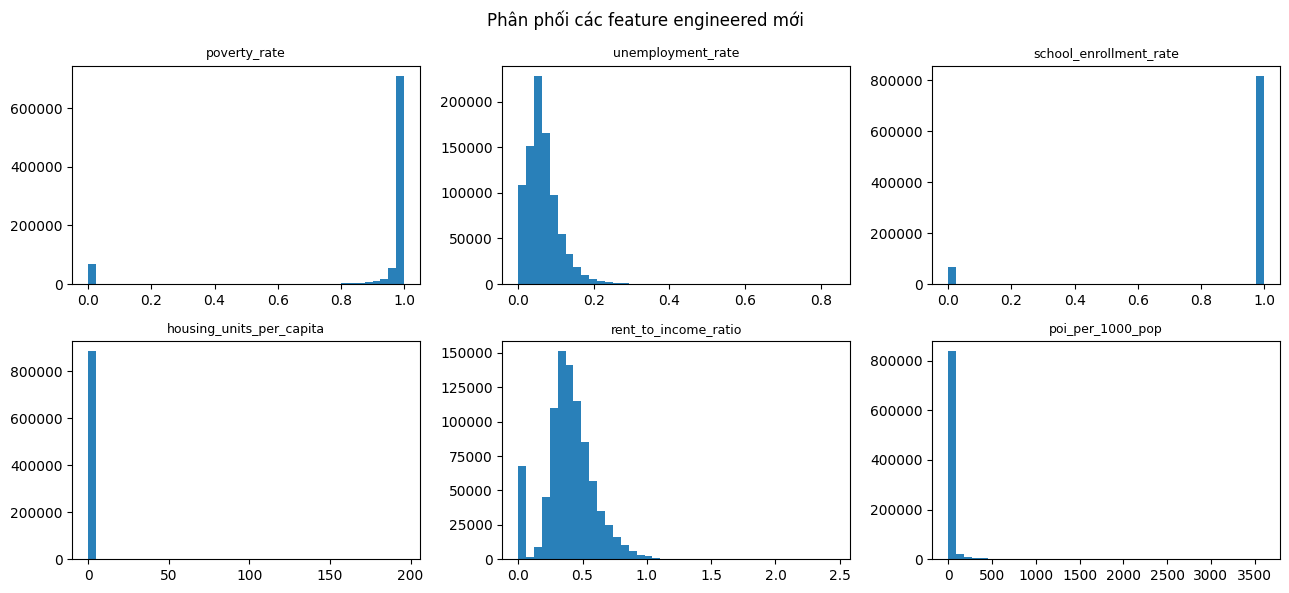

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.ravel(), new_feats):
    ax.hist(df_clean[col], bins=40, color="#2980b9")
    ax.set_title(col, fontsize=9)
fig.suptitle("Phân phối các feature engineered mới")
plt.tight_layout()
plt.show()

## Bước 4 — Vì sao log-transform target?

`price` lệch phải rất mạnh (vài căn nhà siêu đắt kéo dài đuôi phân phối) —
đây là lý do dùng `log1p(price)` làm target khi train model, thay vì train
trực tiếp trên USD.

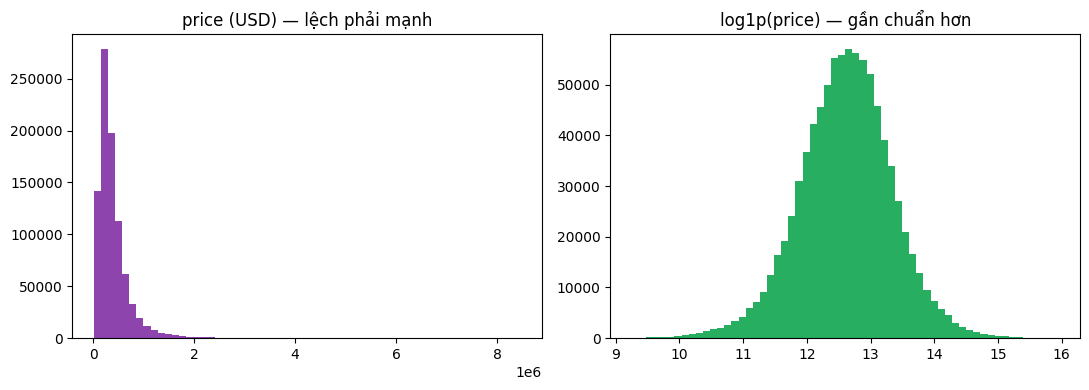

count    8.840920e+05
mean     3.913289e+05
std      3.445383e+05
min      1.046432e+04
25%      1.897063e+05
50%      3.050190e+05
75%      4.797111e+05
max      8.463116e+06
Name: price, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df_clean[TARGET], bins=60, color="#8e44ad")
axes[0].set_title(f"{TARGET} (USD) — lệch phải mạnh")
axes[1].hist(np.log1p(df_clean[TARGET]), bins=60, color="#27ae60")
axes[1].set_title(f"log1p({TARGET}) — gần chuẩn hơn")
plt.tight_layout()
plt.show()
print(df_clean[TARGET].describe())

## Bước 5 — Time-based split (KHÔNG random split)

Vì đây là panel data (zipcode x tháng), phải chia train/test theo thời gian.
Xem số lượng dòng theo từng tháng ở train vs test để chắc chắn split hợp lý
(không có chồng lấn thời gian).

[split] Train: 772,024 rows (<= 2022-06-30) | Test: 112,068 rows (> 2022-06-30)


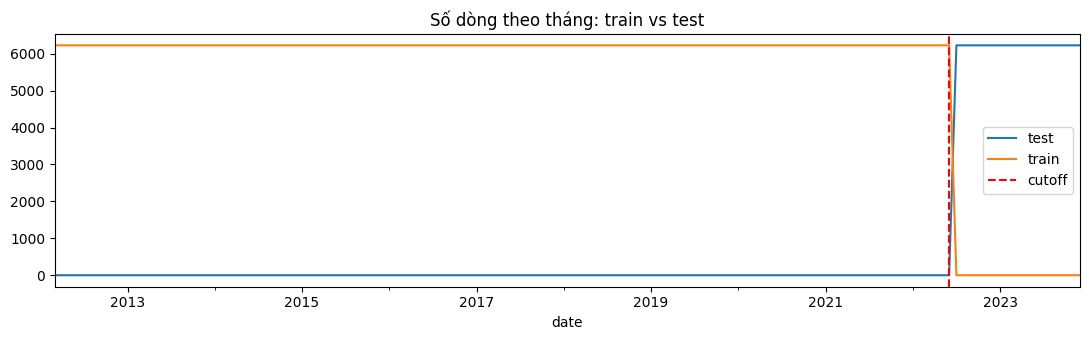

In [9]:
train_df, test_df = time_based_split(df_clean, cutoff_date=CUTOFF_DATE)

monthly_counts = df_clean.assign(
    split=np.where(df_clean["date"] <= CUTOFF_DATE, "train", "test")
).groupby([pd.Grouper(key="date", freq="MS"), "split"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(11, 3.5))
monthly_counts.plot(ax=ax)
ax.axvline(pd.Timestamp(CUTOFF_DATE), color="red", linestyle="--", label="cutoff")
ax.set_title("Số dòng theo tháng: train vs test")
ax.legend()
plt.tight_layout()
plt.show()

## Bước 6 — Sinh prediction để học trọng số meta-model (Rolling-window CV)

`TimeSeriesSplit(n_splits=N_SPLITS_TOTAL)` tạo ra `N_SPLITS_TOTAL` fold theo
kiểu expanding window (fold đầu train ít, fold cuối train nhiều). Thay vì
dùng TẤT CẢ fold (cách cũ, có bias vì fold đầu quá nhỏ) hay chỉ 1 holdout duy
nhất (blending, ít bias nhưng nhiều variance), ở đây **chỉ giữ lại
`N_FOLDS_USED` fold CUỐI CÙNG** — những fold mà train size đã đủ lớn (ví dụ
với `N_SPLITS_TOTAL=6, N_FOLDS_USED=3`, fold được giữ có train size ~57%,
~71%, ~86% train set — không còn fold nào quá nhỏ).

- Mỗi fold: base model train trên `fold-train`, predict trên `fold-val` (chưa
  từng thấy nhãn thật) → đó là prediction dùng để học trọng số meta-model.
- `encode_and_scale` được **re-fit riêng cho từng fold-train** — vẫn tránh
  leakage qua zipcode target-encoding như các bản trước.
- Có nhiều fold (không chỉ 1 holdout) → nhiều "cửa sổ thời gian" khác nhau để
  học trọng số, giảm rủi ro trọng số bị lệch theo đặc thù riêng của 1 giai
  đoạn — đây là điểm cải thiện so với blending.

In [10]:
def get_base_models():
    return {
        "elasticnet": ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=10000, random_state=RANDOM_SEED),
        "random_forest": RandomForestRegressor(
            n_estimators=300, max_depth=18, min_samples_leaf=3,
            n_jobs=-1, random_state=RANDOM_SEED),
        "xgboost": XGBRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=7,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
            n_jobs=-1, random_state=RANDOM_SEED),
    }

def generate_rolling_oof_predictions(train_df, n_splits_total=N_SPLITS_TOTAL, n_folds_used=N_FOLDS_USED):
    """
    Rolling-window CV: tạo n_splits_total fold bằng TimeSeriesSplit (expanding
    window), nhưng CHỈ dùng n_folds_used fold CUỐI CÙNG (train size đã đủ
    lớn) để sinh prediction cho meta-model. Tránh bias của cách cũ (dùng cả
    fold rất nhỏ ở đầu) trong khi vẫn có nhiều hơn 1 "cửa sổ thời gian" so với
    blending (giảm variance khi học trọng số).
    """
    tscv = TimeSeriesSplit(n_splits=n_splits_total)
    all_folds = list(tscv.split(train_df))
    folds = all_folds[-n_folds_used:]   # chỉ giữ các fold cuối

    base_models = get_base_models()
    n_rows = len(train_df)
    oof_preds = {name: np.full(n_rows, np.nan) for name in base_models}
    oof_mask = np.zeros(n_rows, dtype=bool)

    for fold_idx, (tr_idx, val_idx) in enumerate(folds, start=1):
        fold_train_df = train_df.iloc[tr_idx]
        fold_val_df = train_df.iloc[val_idx]
        X_tr, X_val, y_tr, y_val, _ = encode_and_scale(fold_train_df, fold_val_df)
        print(f"  Fold {fold_idx}/{len(folds)}: train={len(X_tr):,} "
              f"({len(X_tr)/n_rows*100:.0f}% train set) | val={len(X_val):,}")
        for name, model in base_models.items():
            m = clone(model)
            m.fit(X_tr, y_tr)
            oof_preds[name][val_idx] = m.predict(X_val)
        oof_mask[val_idx] = True

    oof_df = pd.DataFrame(oof_preds)[oof_mask].reset_index(drop=True)
    oof_y = transform_target(train_df[TARGET].reset_index(drop=True))[oof_mask].reset_index(drop=True)
    print(f"\n  -> Tổng {oof_mask.sum():,}/{n_rows:,} dòng có prediction từ "
          f"{len(folds)} fold cuối (không có fold nào train dưới "
          f"{len(all_folds[-n_folds_used][0])/n_rows*100:.0f}% dữ liệu)")
    return oof_df, oof_y

In [11]:
oof_df, oof_y = generate_rolling_oof_predictions(train_df, n_splits_total=N_SPLITS_TOTAL, n_folds_used=N_FOLDS_USED)
oof_df.describe()

[encode] Target-encoded: zipcode (3558 groups)
[encode] One-hot encoded: city (17 columns)
[scale]  StandardScaled 41 numeric columns
[encode] Final feature count: 60
  Fold 1/3: train=441,157 (57% train set) | val=110,289
[encode] Target-encoded: zipcode (4448 groups)
[encode] One-hot encoded: city (20 columns)
[scale]  StandardScaled 41 numeric columns
[encode] Final feature count: 63
  Fold 2/3: train=551,446 (71% train set) | val=110,289
[encode] Target-encoded: zipcode (5337 groups)
[encode] One-hot encoded: city (24 columns)
[scale]  StandardScaled 41 numeric columns
[encode] Final feature count: 67
  Fold 3/3: train=661,735 (86% train set) | val=110,289

  -> Tổng 330,867/772,024 dòng có prediction từ 3 fold cuối (không có fold nào train dưới 57% dữ liệu)


,elasticnet,random_forest,xgboost
count,330867.000000,330867.000000,330867.000000
mean,12.550785,12.552122,12.532608
std,0.178491,0.216247,0.207657
min,11.535508,11.456896,11.506456
25%,12.399809,12.397853,12.388953
50%,12.546985,12.560198,12.538485
75%,12.709868,12.692070,12.671237
max,13.846779,13.748762,13.874224


**Quan sát**: nhìn `std`/`max` của từng cột — nếu 1 model cho ra giá trị cực
đoan bất thường, đó là dấu hiệu model đó dễ bất ổn. So các giá trị này với
RMSE trên các fold ở cell dưới để đánh giá model nào đáng tin hơn khi học
trọng số. Vì giờ base model luôn train trên ≥50% train set (không có fold
quá nhỏ như bản TimeSeriesSplit gốc), các giá trị này nên ổn định hơn hẳn.

In [12]:
print("RMSE (log scale) của từng base model TRÊN các fold rolling-window:")
for col in oof_df.columns:
    rmse = np.sqrt(mean_squared_error(oof_y, oof_df[col]))
    print(f"  {col:15s}: {rmse:.4f}")

RMSE (log scale) của từng base model TRÊN các fold rolling-window:
  elasticnet     : 0.7578
  random_forest  : 0.7596
  xgboost        : 0.7234


## Bước 7 — Train meta-model dạng TỔ HỢP LỒI

⚠️ **Vấn đề thực tế phát hiện khi xây pipeline này**: nếu dùng `Ridge`/`ElasticNet`
thường (có intercept, hệ số có thể âm) làm meta-model, hệ số học được có thể
KHÔNG tổng bằng 1 và có intercept lớn. Khi áp dụng lên prediction của base
model *cuối cùng* (train trên full train set — quy mô khác với model dùng để
tạo prediction học trọng số), sai lệch này có thể bị khuếch đại theo cấp số
nhân sau `expm1()` — nhà càng đắt càng bị dự đoán sai nặng.

**Giải pháp**: ép trọng số **không âm, tổng = 1, không intercept** (tổ hợp
lồi, giải bằng `scipy.optimize.nnls`). Về mặt toán học, dự đoán stacked luôn
nằm trong khoảng [min, max] của các base model tại mọi điểm — không thể
ngoại suy ra ngoài phạm vi hợp lý.

So trọng số học được ở đây với `InverseRMSEMetaModel` (bạn tự thêm ở cuối
notebook) để xem 2 cách tính trọng số có đồng thuận không.

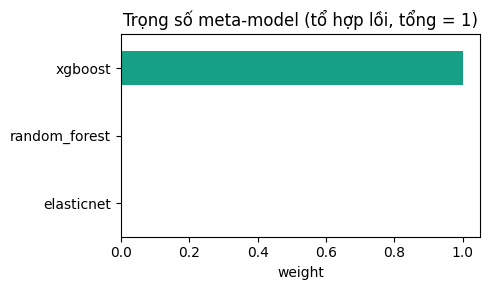

{'elasticnet': np.float64(0.0), 'random_forest': np.float64(0.0), 'xgboost': np.float64(1.0)}


In [13]:
class ConvexMetaModel:
    def __init__(self):
        self.weights_ = None
        self.columns_ = None

    def fit(self, X, y):
        self.columns_ = list(X.columns)
        w, _ = nnls(X.values, y.values)
        if w.sum() == 0:
            w = np.ones(len(self.columns_))
        self.weights_ = w / w.sum()
        return self

    def predict(self, X):
        X = X[self.columns_]
        return X.values @ self.weights_

meta_model = ConvexMetaModel().fit(oof_df, oof_y)
weights = dict(zip(meta_model.columns_, meta_model.weights_))

fig, ax = plt.subplots(figsize=(5, 3))
pd.Series(weights).sort_values().plot(kind="barh", ax=ax, color="#16a085")
ax.set_title("Trọng số meta-model (tổ hợp lồi, tổng = 1)")
ax.set_xlabel("weight")
plt.tight_layout()
plt.show()
print(weights)

**Quan sát**: so trọng số này với RMSE trên rolling-window fold ở bước
trước — model nào có RMSE thấp hơn thường được gán trọng số cao hơn. Vì các
fold dùng ở đây đều có train size ≥50% (không còn fold nhỏ như
TimeSeriesSplit gốc), trọng số nên phản ánh sát hơn sức mạnh thật của từng
model khi dự đoán trên test — đặc biệt kỳ vọng RandomForest được trọng số
cao hơn so với cách TimeSeriesSplit toàn bộ fold trước đây.

## Bước 8 — Train base models cuối cùng trên TOÀN BỘ train set

Khác với các model dùng để tạo prediction cho rolling-window CV (train trên
từng fold, ~57-86% train set), các base model ở đây được train lại trên
**toàn bộ train set** (100%) để tận dụng hết dữ liệu — đây là bộ model thực
sự dùng để dự đoán trên test set.

In [14]:
X_train, X_test, y_train, y_test, artifacts = encode_and_scale(train_df, test_df)
y_test_price = artifacts["y_raw_test"].values

def evaluate(y_true_price, y_pred_price, label):
    rmse = np.sqrt(mean_squared_error(y_true_price, y_pred_price))
    mae = mean_absolute_error(y_true_price, y_pred_price)
    r2 = r2_score(y_true_price, y_pred_price)
    mape = np.mean(np.abs((y_true_price - y_pred_price) / y_true_price)) * 100
    return {"model": label, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

base_models = get_base_models()
base_models_fitted = {}
base_test_preds_log = {}
base_test_preds_price = {}
results = []

for name, model in base_models.items():
    model.fit(X_train, y_train)
    base_models_fitted[name] = model
    preds_log = model.predict(X_test)
    preds_price = np.expm1(preds_log)
    base_test_preds_log[name] = preds_log
    base_test_preds_price[name] = preds_price
    results.append(evaluate(y_test_price, preds_price, name))

pd.DataFrame(results).set_index("model").round(4)

[encode] Target-encoded: zipcode (6226 groups)
[encode] One-hot encoded: city (30 columns)
[scale]  StandardScaled 41 numeric columns
[encode] Final feature count: 73


,RMSE,MAE,R2,MAPE
model,,,,
elasticnet,124942.4439,72948.0329,0.9138,13.4189
random_forest,62160.7344,32082.7073,0.9787,5.5385
xgboost,62402.7174,32861.5519,0.9785,5.9104


## Bước 9 — Dự đoán STACKED trên test set & so sánh công bằng

So sánh stacked với **base model tốt nhất** (không phải model tệ nhất — so
kiểu đó là ngụy biện).

In [15]:
meta_test_X = pd.DataFrame(base_test_preds_log)[list(base_models.keys())]
stacked_preds_log = meta_model.predict(meta_test_X)
stacked_preds_price = np.expm1(stacked_preds_log)
results.append(evaluate(y_test_price, stacked_preds_price, "STACKED"))

results_df = pd.DataFrame(results).set_index("model").round(4)
display(results_df)

best_single = results_df.drop("STACKED").sort_values("RMSE").iloc[0]
stacked_row = results_df.loc["STACKED"]
improvement = (best_single["RMSE"] - stacked_row["RMSE"]) / best_single["RMSE"] * 100
print(f"\nStacked so với base model tốt nhất ({best_single.name}): "
      f"RMSE {'giảm' if improvement > 0 else 'tăng'} {abs(improvement):.2f}%")

,RMSE,MAE,R2,MAPE
model,,,,
elasticnet,124942.4439,72948.0329,0.9138,13.4189
random_forest,62160.7344,32082.7073,0.9787,5.5385
xgboost,62402.7174,32861.5519,0.9785,5.9104
STACKED,62402.7171,32861.5518,0.9785,5.9104



Stacked so với base model tốt nhất (random_forest): RMSE tăng 0.39%


## Bước 10 — Phân tích chiều sâu: tương quan residual giữa base models

Đây là bằng chứng trực tiếp cho việc 3 base model có thực sự "nhìn" dữ liệu
khác nhau hay không:
- corr thấp (~0.3–0.7) → base model bổ trợ nhau tốt, stacking có cơ sở để cải thiện.
- corr rất cao (>0.9) → base model gần như dự đoán giống nhau, stacking sẽ ít
  hoặc không cải thiện thêm.

,elasticnet,random_forest,xgboost
elasticnet,1.000,0.55,0.592
random_forest,0.550,1.00,0.780
xgboost,0.592,0.78,1.000


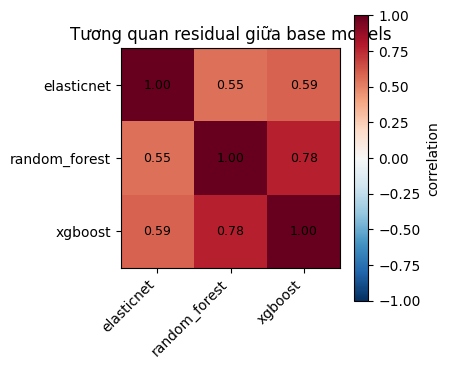

In [16]:
y_test_log = np.log1p(y_test_price)
residuals = pd.DataFrame({name: y_test_log - preds for name, preds in base_test_preds_log.items()})
corr = residuals.corr()
display(corr.round(3))

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, label="correlation")
ax.set_title("Tương quan residual giữa base models")
plt.tight_layout()
plt.show()

## Bước 11 — Feature importance: RandomForest vs XGBoost

Nếu 2 model rank feature khác nhau đáng kể, đó là bằng chứng bổ sung cho việc
chúng "nhìn" dữ liệu theo cách khác nhau (cùng chiều với phân tích residual
ở trên).

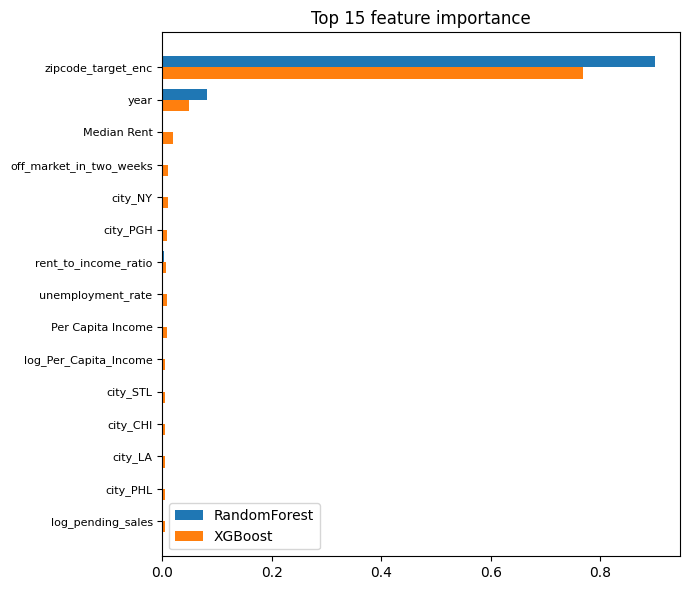

Spearman rank-correlation feature importance (RF vs XGB): 0.561


In [17]:
imp_df = pd.DataFrame({
    "random_forest": base_models_fitted["random_forest"].feature_importances_,
    "xgboost": base_models_fitted["xgboost"].feature_importances_,
}, index=X_train.columns)
imp_df["avg"] = imp_df.mean(axis=1)
imp_df = imp_df.sort_values("avg", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 6))
x = np.arange(len(imp_df)); width = 0.35
ax.barh(x - width/2, imp_df["random_forest"], height=width, label="RandomForest")
ax.barh(x + width/2, imp_df["xgboost"], height=width, label="XGBoost")
ax.set_yticks(x); ax.set_yticklabels(imp_df.index, fontsize=8)
ax.invert_yaxis(); ax.legend(); ax.set_title("Top 15 feature importance")
plt.tight_layout()
plt.show()

rank_corr = imp_df[["random_forest", "xgboost"]].corr(method="spearman").iloc[0, 1]
print(f"Spearman rank-correlation feature importance (RF vs XGB): {rank_corr:.3f}")

## Bước 12 — Predicted vs Actual: nhìn trực quan model sai ở đâu

Các điểm càng gần đường chéo đỏ càng chính xác. Chú ý các điểm lệch xa —
thường là nhà giá rất cao/thấp bất thường, nơi model dễ sai nhất.

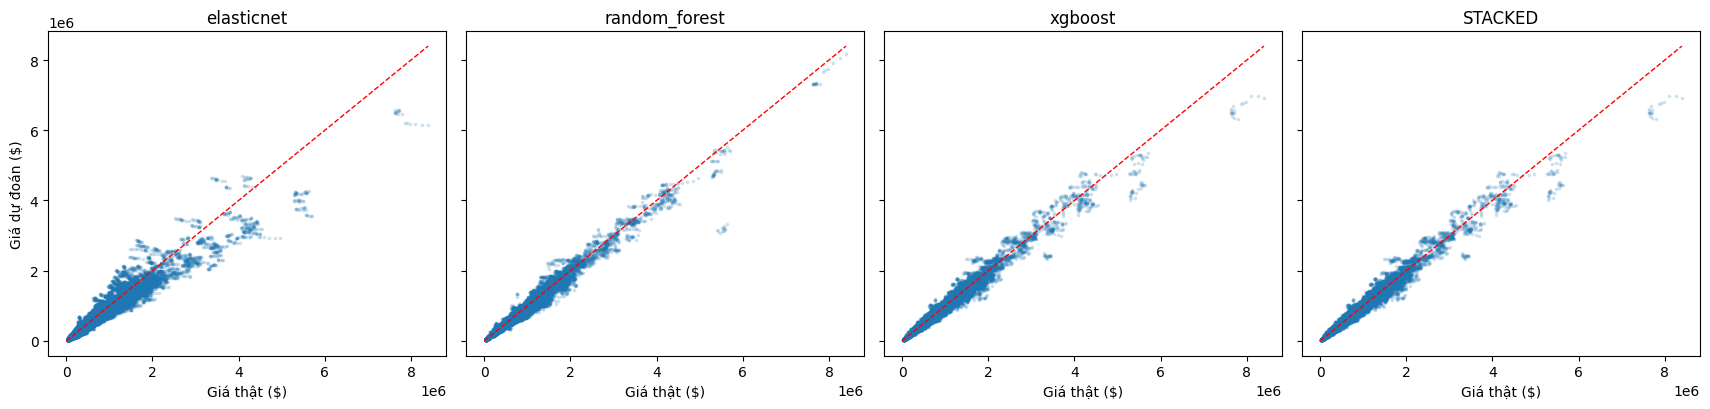

In [18]:
preds_dict = {**base_test_preds_price, "STACKED": stacked_preds_price}
fig, axes = plt.subplots(1, len(preds_dict), figsize=(4.3*len(preds_dict), 4.2), sharey=True)
for ax, (name, preds) in zip(axes, preds_dict.items()):
    ax.scatter(y_test_price, preds, s=3, alpha=0.15)
    lims = [0, max(y_test_price.max(), preds.max())]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_xlabel("Giá thật ($)"); ax.set_title(name)
axes[0].set_ylabel("Giá dự đoán ($)")
plt.tight_layout()
plt.show()

## Tổng kết

Chạy lại từ trên xuống, quan sát 3 con số quan trọng nhất để đánh giá stacking
có đáng công sức không:

1. **Bảng so sánh RMSE/MAE/R²/MAPE** (bước 9) — stacking có thực sự vượt base
   model tốt nhất không, hay chỉ vượt trung bình?
2. **Ma trận tương quan residual** (bước 10) — corr càng thấp, stacking càng
   có cơ sở lý thuyết để cải thiện.
3. **Trọng số meta-model** (bước 7) vs **RMSE trên rolling-window fold**
   (bước 6) — giải thích base model nào đóng góp nhiều, và trọng số có phản
   ánh đúng sức mạnh thật của model khi có đủ dữ liệu hay không (đặc biệt
   RandomForest).

> Nếu muốn kết quả đáng tin hơn cho báo cáo cuối, đặt `SAMPLE_FRAC = 1.0` và
> tăng `n_estimators` của RandomForest/XGBoost, rồi chạy lại toàn bộ notebook.
> Có thể thử đổi `N_SPLITS_TOTAL`/`N_FOLDS_USED` (ví dụ 8/4) để xem trọng số
> meta-model có ổn định không.

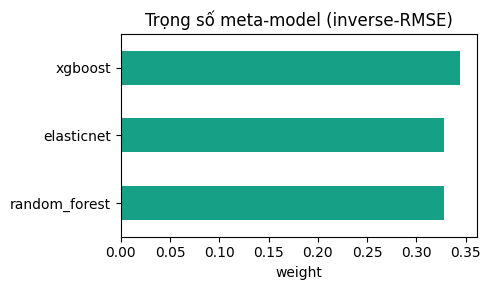

{'elasticnet': np.float64(0.328377257410711), 'random_forest': np.float64(0.32760713441552286), 'xgboost': np.float64(0.34401560817376614)}
{'elasticnet': np.float64(0.7578469344153564), 'random_forest': np.float64(0.7596284443085014), 'xgboost': np.float64(0.7233965318652864)}


In [19]:
class InverseRMSEMetaModel:
    def __init__(self):
        self.weights_ = None
        self.columns_ = None
        self.rmses_ = None

    def fit(self, X, y):
        """X: DataFrame các cột dự đoán (log-scale), y: giá trị thật (log-scale)."""
        self.columns_ = list(X.columns)
        rmses = {
            col: np.sqrt(mean_squared_error(y, X[col]))
            for col in self.columns_
        }
        self.rmses_ = rmses
        inv = np.array([1.0 / rmses[c] for c in self.columns_])
        self.weights_ = inv / inv.sum()
        return self

    def predict(self, X):
        X = X[self.columns_]
        return X.values @ self.weights_

meta_model = InverseRMSEMetaModel().fit(oof_df, oof_y)
weights = dict(zip(meta_model.columns_, meta_model.weights_))

fig, ax = plt.subplots(figsize=(5, 3))
pd.Series(weights).sort_values().plot(kind="barh", ax=ax, color="#16a085")
ax.set_title("Trọng số meta-model (inverse-RMSE)")
ax.set_xlabel("weight")
plt.tight_layout()
plt.show()
print(weights)
print(meta_model.rmses_)

In [20]:
avg_log_price = (base_test_preds_log["random_forest"] + base_test_preds_log["xgboost"]) / 2
simple_avg_price_v2 = np.expm1(avg_log_price)
results.append(evaluate(y_test_price, simple_avg_price_v2, "SIMPLE_AVG_LOGSPACE"))
pd.DataFrame(results).set_index("model").round(4)
df_results = pd.DataFrame(results).set_index("model")
df_results = df_results[~df_results.index.duplicated(keep="first")]
df_results.round(4)

,RMSE,MAE,R2,MAPE
model,,,,
elasticnet,124942.4439,72948.0329,0.9138,13.4189
random_forest,62160.7344,32082.7073,0.9787,5.5385
xgboost,62402.7174,32861.5519,0.9785,5.9104
STACKED,62402.7171,32861.5518,0.9785,5.9104
SIMPLE_AVG_LOGSPACE,58619.9241,30958.8293,0.9810,5.4668
